### Exploratory Data Analysis - 

It is the process of understanding your dataset before applying any machine learning algorithms.

Think of it like a doctor examining a patient before prescribing medicine.

Before training a model, you ask:

How many rows and columns are there?
Are there missing values?
Are there duplicate records?
What is the distribution of data?
Are there outliers?
Which features are correlated?
Which features seem important?
Are there any unusual patterns?

That's EDA. 

Basically in Data Analysis Process, there are 5 steps - 
1. Asking Questions
2. Data Wrangling - In this, there are 3 more steps
    - Data gathering
    - Data assessing
    - Data cleaning
3. EDA (Exploratory Data Analysis)
4. Writing conclusions
5. Presenting in front of others

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('Datasets/train.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### Why do EDA

- Model building
- Analysis and reporting
- Validate assumptions
- Handling missing values
- feature (column) engineering
- detecting outliers

In [ ]:
# Remember it is an iterative process!
# It is not a one time thing!

### # Steps while doing EDA

1. Labelling columns -> numerical / categorical / mixed
2. Univariate analysis
3. Bi-variate analysis
4. Multivariate analysis
5. Feature Engineering / Outlier Detection / Computing Missing Values

**REMEMBER IT IS AN ITERATIVE PROCESS** - We might have to go back to step 1 all the way after step 5, if needed! 

After becoming 100% sure, that everything is complete, then you can draw conclusions!

### 1. Column Types
1. Numerical - Age, Fare, PassengerId
2. Categorical - Survived, Pclassm Sex, SibSp, Parch, Embarked
3. Mixed - Name, Ticket, Cabin
    

### 2. Univariate Analysis 
**Meaning - Analysis done on a single column**

Univariate analysis focuses on analyzing each feature (meaning - column) in the dataset independently.

- **Distribution analysis**: The distribution of each feature is examined to identify its shape, central tendency, and dispersion.

- **Identifying potential issues**: Univariate analysis helps in identifying potential problems with the data such as outliers, skewness, and missing values

#### The shape of a data distribution refers to its overall pattern or form as it is represented on a graph. Some common shapes of data distributions include:

- **Normal Distribution**: A symmetrical and bell-shaped distribution where the mean, median, and mode are equal and the majority of the data falls in the middle of the distribution with gradually decreasing frequencies towards the tails.

- **Skewed Distribution**: A distribution that is not symmetrical, with one tail being longer than the other. It can be either positively skewed (right-skewed) or negatively skewed (left-skewed).

- **Bimodal Distribution**: A distribution with two peaks or modes.

- **Uniform Distribution**: A distribution where all values have an equal chance of occurring.

The shape of the data distribution is important in identifying the presence of outliers, skewness, and the type of statistical tests and models that can be used for further analysis.

In [ ]:
# Now let's start with EDA 

df.head()

In [ ]:
# Now keep in mind that we are performing EDA, to predict the survival of a passenger on the titanic ship
# Now, it's pretty common sense, that it's survival won't be based on it's passenger id
# Therefore, ignore that column!

# Let's start univariate analysis from 'Age' column

### Age

**conclusions** -
1. Age is normally distributed
2. 20% of the values are missing
3. There are some outliers 

In [ ]:
df['Age'].describe()

In [ ]:
sns.histplot(df['Age'])

In [ ]:
sns.kdeplot(df['Age'])
# This tells us about the skewness of our data!


In [ ]:
# In order to find the skew of our data --> 
df['Age'].skew()

# Since the value is near about 0, we can say that our data is normal, which is a good thing,
# because in future, when we will be applying many statistical tests, they assume that our data is already normal distribution 
# Therefore, this is a good thing!

In [ ]:
sns.boxplot(df['Age'])

In [ ]:
# Now from this we can see the outliers in our data! 
# But to verify, whether these are genuinely outliers, or by mistake they have been considered as outliers, 
# we have to see the data for that!
# What I mean by this is that, let's say there's an age of 300 in our data by mistake, then that's obviously an outlier, but other values, like 
# here we can see that any value above around 65 is an outlier. But what if these are actually the ages from 65-80 of some genuine people
# Then in that case, we cannot consider this as an outlier

# To see this, we have to do --> 

df[df['Age'] > 65]

In [ ]:
# Now let's see if we have missing values as well!

print(len(df['Age']))
print(df['Age'].isnull().sum())        # We ahve total of 177 missing values from a total of 891!

print(df['Age'].isnull().sum() / len(df['Age']))        # Around 19% of values from our data is missing, which is too much!

### Fare

**conclusions** - 

1. Data is highly skewed (Positively skewed)
2. Fare column actually contains the group fare and not the individual fare. (This might be an issue)
3. We need to create a new column called 'individual_fare'

In [ ]:
df['Fare'].describe()

In [ ]:
sns.histplot(df['Fare'])

In [ ]:
sns.kdeplot(df['Fare'])

# We can say that, our data is 'Negatively Skewed' (OR left-skewed)

In [ ]:
df['Fare'].skew()
# Since this value is greater than 0, it is highly positively skewed distribution!

In [ ]:
# Identifying outliers
sns.boxplot(df['Fare'])

# As we can see, there are too many outliers in our data!
# Roughly any value above 100-200 $ is an outlier!


In [ ]:
df[df['Fare'] > 250]

# As you can see from the data, what we were assuming is that, the 'Fare' column is the ticket price each person has paid!
# But in reality, it's the total price that the entire family (if travelling along with family) has paid!
# Therefore, there are no outliers as such, rather, these are families travelling together and that's the reason why their 'Fare' price is so high!

In [ ]:
# Now in future, we will have to perform feature engineering to somehow calculate the 'Fare' for each person travelling on the ship!

In [ ]:
df['Fare'].isnull().sum()

### Steps of doing Univariate Analysis on Categorical columns

**Descriptive Statistics**: Compute the frequency distribution of the categories in the column. This will give a general understanding of the distribution of the categories and their relative frequencies.

**Visualizations**: Create visualizations to explore the distribution of the categories. Some common visualizations for categorical data include count plots and pie charts. These visualizations provide a visual representation of the distribution of the categories and can help identify any patterns or anomalies in the data.

**Missing Values**: Check for missing values in the data and decide how to handle them. Missing values can be imputed or excluded from the analysis, depending on the research question and the data set.

**Conclusion**: Summarize the findings of the EDA and make decisions about how to proceed with further analysis.

### Survived

**conclusions** - 

1.  The accident was so deadly that nearly 62% of the people on the ship were dead and only 38% of the people survived it!

In [ ]:
df['Survived'].value_counts()

# 0 - people died
# 1 - people survived

In [ ]:
sns.barplot(df['Survived'].value_counts())
# sns.catplot(df['Survived'].value_counts(), kind='bar')

In [ ]:
laebls = ['Dead', 'Survived']
plt.pie(df['Survived'].value_counts(), labels=labels, autopct='%0.1f%%')
plt.legend()

In [ ]:
df['Survived'].isnull().sum()

### Pclass

**conclusions** - 
1. Surprisingly more people travelled in Pclass-1 and less people travelled in Pclass-2

In [7]:
df['Pclass'].value_counts()
# 3 - Middle class
# 1 - Rich people
# 2 - Upper middle class

Pclass
3    491
1    216
2    184
Name: count, dtype: int64

In [ ]:
sns.barplot(df['Pclass'].value_counts())
# sns.catplot(df['Pclass'].value_counts(), kind='bar')

In [ ]:
labels = ['Middle Class', 'Rich people', 'Upper Middle Class']
plt.pie(df['Pclass'].value_counts(), labels=labels, autopct='%0.1f%%')

In [ ]:
df['Pclass'].isnull().sum()

### Sex

**conclusions** - 

In [ ]:
df['Sex'].value_counts()

In [ ]:
sns.barplot(df['Sex'].value_counts())
# sns.catplot(df['Sex'].value_counts(), kind='bar')

In [ ]:
labels = ['Male', 'Female']
plt.pie(df['Sex'].value_counts(), labels=labels, autopct='%0.1f%%')

In [ ]:
df['Sex'].isnull().sum()

###  SibSp & Parch

**conclusions** - 
1. 

In [ ]:
df['SibSp'].value_counts()

In [ ]:
sns.barplot(df['SibSp'].value_counts())
# sns.catplot(df['SibSp'].value_counts(), kind='bar')

In [ ]:
labels = ['0', '1', '2', '4', '3', '8', '5']
plt.pie(df['SibSp'].value_counts(), labels=labels, autopct='%0.1f%%')

In [ ]:
df['SibSp'].isnull().sum()

### Parch

**conclusions** -
1. 'Parch' and 'SibSp' can be merged to form a new column called 'family_size'
2. We can create a new column called 'is_alone'

In [ ]:
df['Parch'].value_counts()

In [ ]:
sns.barplot(df['Parch'].value_counts())
# sns.catplot(df['Parch'].value_counts(), kind='bar')

In [ ]:
labels = ['0', '1', '2', '5', '3', '4', '6']
plt.pie(df['Parch'].value_counts(), labels=labels, autopct='%0.1f%%')

In [ ]:
df['Parch'].isnull().sum()

### Embarked

**concludions** - 
1. 

In [ ]:
df['Embarked'].value_counts()

# S - Southampton (Departure)
# C - Cherbourg (First Stop)
# Q - Queenstown (Second Stop)

In [ ]:
sns.barplot(df['Embarked'].value_counts())
# sns.catplot(df['Embarked'].value_counts(), kind='bar')

In [ ]:
labels = ['Southampton', 'Cherbourg', 'Queenstown']
plt.pie(df['Embarked'].value_counts(), labels=labels, autopct='%0.1f%%')

### Univariate analysis on Mixed Columns

In order to do univariate analysis on mixed columns, we have to first do feature engineering and convert them into a simpler form such that we can then perform univariate analysis on them!


Basically convert them into categorical or numerical data!

### Steps of doing Bivariate Analysis

- Select 2 cols
- Understand type of relationship
    1. **Numerical - Numerical**<br>
        a. You can plot graphs like scatterplot(regression plots), 2D histplot, 2D KDEplots<br>
        b. Check correlation coefficent to check linear relationship
    2. **Numerical - Categorical** - create visualizations that compare the distribution of the numerical data across different categories of the categorical data.<br>
        a. You can plot graphs like barplot, boxplot, kdeplot violinplot even scatterplots<br>
    3. **Categorical - Categorical**<br>
        a. You can create cross-tabulations or contingency tables that show the distribution of values in one categorical column, grouped by the values in the other categorical column.<br>
        b. You can plots like heatmap, stacked barplots, treemaps
        
- Write your conclusions

In [3]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
# While doing bivariate analysis, what we should do is, select the most important column in our dataframe.
# Because we are doing survival prediction (ML Model), the most important column would be 'Survived'
# Now we have to plot a graph between 'Survived' and all the rest of the columns 
# We should only plot a graph only if it's meaningful, not just for the sake of doing it!

In [5]:
# Another import column is 'Age' because there are a few missing values and also there can be a relationship that can be drawn, 
# between the 2 columns

### Survived v/s Pclass

**conclusions** - <br> 
Thus, we can surely say that, travelling in Pclass 3 was very dangerous as compared to Pclass 1 as nearly 76% people died

<Axes: xlabel='Pclass', ylabel='Survived'>

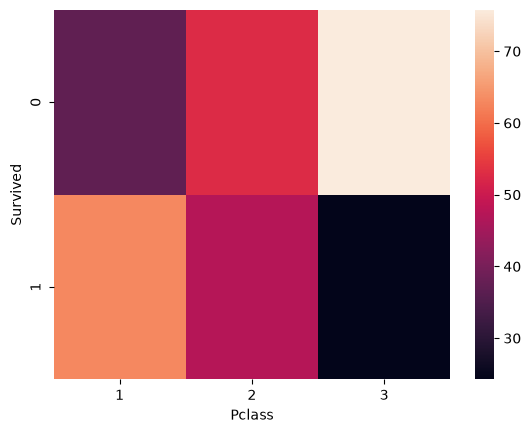

In [13]:
# Now first let's select 2 columns - 'Survived' and 'Pclass'
# Both are categorical
# Therefore, we'll have to create a crosstab between the two!


pd.crosstab(df['Survived'], df['Pclass'])

# Now instead of talking in terms of absolute numbers, let's talk in terms of percentages
# In order to do that - 

# pd.crosstab(df['Survived'], df['Pclass'], normalize='columns')*100
sns.heatmap(pd.crosstab(df['Survived'], df['Pclass'], normalize='columns')*100)

Sex          female       male
Survived                      
0         25.796178  81.109185
1         74.203822  18.890815


<Axes: xlabel='Sex', ylabel='Survived'>

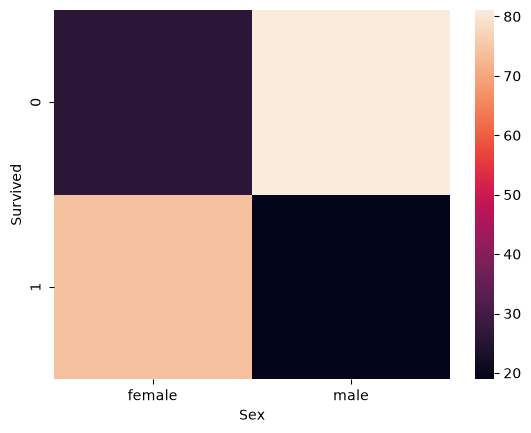

In [17]:
# Survived v/s Sex

print(pd.crosstab(df['Survived'], df['Sex'], normalize='columns')*100)
sns.heatmap(pd.crosstab(df['Survived'], df['Sex'], normalize='columns')*100)

Embarked          C          Q          S
Survived                                 
0         44.642857  61.038961  66.304348
1         55.357143  38.961039  33.695652


<Axes: xlabel='Embarked', ylabel='Survived'>

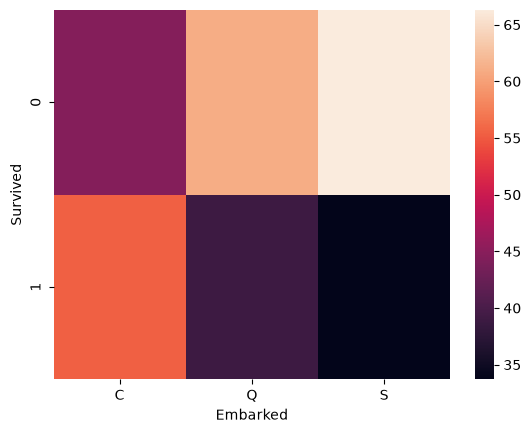

In [ ]:
# Survived v/s Embarked

print(pd.crosstab(df['Survived'], df['Embarked'], normalize='columns')*100)
sns.heatmap(pd.crosstab(df['Survived'], df['Embarked'], normalize='columns')*100)

In [20]:
# By looking at the above graph we can kinda say that percentage of people who survived, are from Cherbourg. 
# 
# But what could be the reason? 
# Is it that because most of them were females? 
# OR 
# Is it because most of them are from Pclass 1

# Let's check!

In [22]:
print(pd.crosstab(df['Sex'], df['Embarked'], normalize='columns')*100)

Embarked          C          Q          S
Sex                                      
female    43.452381  46.753247  31.521739
male      56.547619  53.246753  68.478261


In [23]:
# This couldn't be the case because, the number of females were nearly 44%
# So let's check if the reason for survival was Pclass!?

In [24]:
print(pd.crosstab(df['Pclass'], df['Embarked'], normalize='columns')*100)

Embarked          C          Q          S
Pclass                                   
1         50.595238   2.597403  19.720497
2         10.119048   3.896104  25.465839
3         39.285714  93.506494  54.813665


In [ ]:
# Yes by looking at the above insight, we can conclude that the reason for survival was truly becuase of Pclass! 

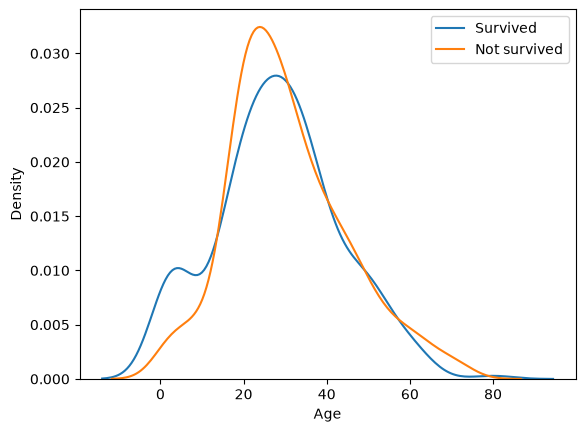

In [32]:
# Numerical - Categorical

# Survived v/s Age
sns.kdeplot(df[df['Survived'] == 1]['Age'], label='Survived')
sns.kdeplot(df[df['Survived'] == 0]['Age'], label='Not survived')
plt.legend()

In [34]:
df[df['Pclass']==1]['Age'].mean()

np.float64(38.233440860215055)

### Feature Engineering

In [35]:
df['SibSp'].value_counts()

SibSp
0    608
1    209
2     28
4     18
3     16
8      7
5      5
Name: count, dtype: int64